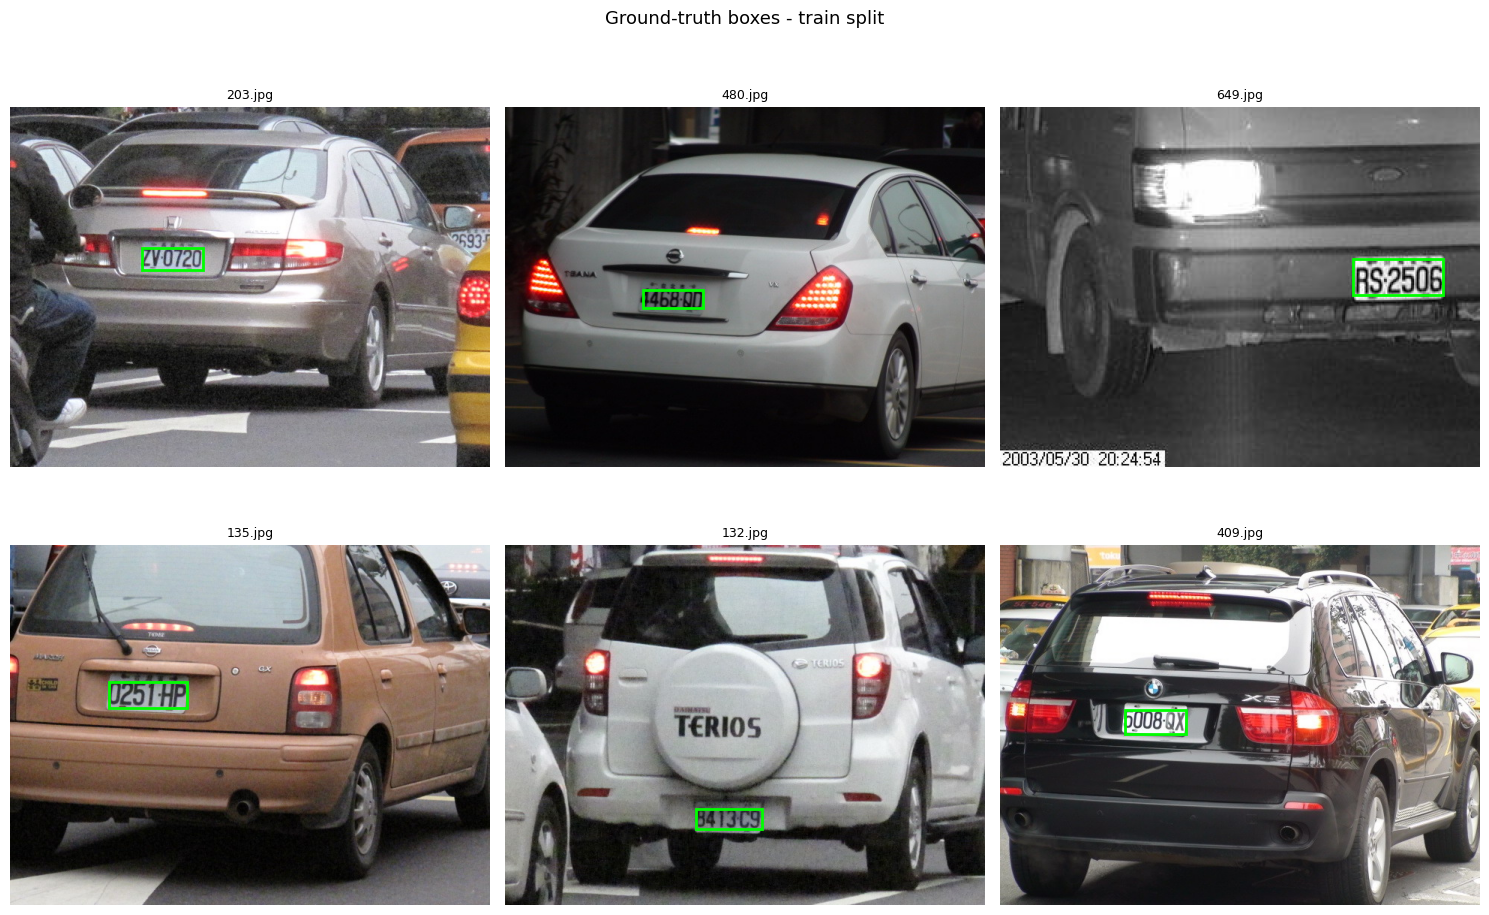

c:\Anaconda\envs\yolo_env\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Saved image with OCR results to C:\Users\Mohamed Walid\Desktop\Internship\Code\results\689_annotated.jpg
OCR results for 689.jpg: {'easyocr': 'RM5635', 'easyocr2': 'RM5635'}
Saved image with OCR results to C:\Users\Mohamed Walid\Desktop\Internship\Code\results\201_annotated.jpg
OCR results for 201.jpg: {'easyocr': '549141', 'easyocr2': '549141'}
Saved image with OCR results to C:\Users\Mohamed Walid\Desktop\Internship\Code\results\121_annotated.jpg
OCR results for 121.jpg: {'easyocr': '9212FA', 'easyocr2': '9212FA'}
Saved image with OCR results to C:\Users\Mohamed Walid\Desktop\Internship\Code\results\352_annotated.jpg
OCR results for 352.jpg: {'easyocr': '2016UX', 'easyocr2': '2016UX'}
Saved image with OCR results to C:\Users\Mohamed Walid\Desktop\Internship\Code\results\324_annotated.jpg
OCR results for 324.jpg: {'easyocr': '1562DE', 'easyocr2': '1562DE'}
Saved image with OCR results to C:\Users\Mohamed Walid\Desktop\Internship\Code\results\304_annotated.jpg
OCR results for 304.jpg: 

In [1]:
from modified_piepeline import run_batch, visualize_ground_truth, evaluate_ocr

# ---------------------------------------------------------------
# 1️⃣  Optional: sanity-check ground-truth bounding boxes
# ---------------------------------------------------------------
visualize_ground_truth(n=6, split="train")

# ---------------------------------------------------------------
# 2️⃣  Run both OCR engines on a sample of images
#      Results are printed live + saved to a log file
# ---------------------------------------------------------------
LOG_PATH = r"C:\Users\Mohamed Walid\Desktop\Internship\Code\results\ocr_log.jsonl"

results = run_batch(
    image_dir   = r"C:\Users\Mohamed Walid\Desktop\Internship\Code\Subset_LE\Image",
    ocr_engines = ('easyocr', 'easyocr2'),   # model 1 (CPU) + model 2 (GPU if available)
    show        = False,                      # set True for pop-up previews (slower)
    output_dir  = r"C:\Users\Mohamed Walid\Desktop\Internship\Code\results",
    log_path    = LOG_PATH,
    sample_size = 10,                         # ← change this to process more/fewer images
    random_seed = 42,
)

# ---------------------------------------------------------------
# 3️⃣  Print a final summary table
# ---------------------------------------------------------------
print(f"\n{'='*55}")
print(f"  Processed {len(results)} images")
print(f"  Log saved to: {LOG_PATH}")
print(f"{'='*55}")

for r in results:
    name  = r.get("image_path", "?").split("\\")[-1]
    ocr   = r.get("ocr_results", {})
    acc   = r.get("ocr_accuracy", {})
    print(f"\n  Image : {name}")
    for eng in ('easyocr', 'easyocr2'):
        txt = ocr.get(eng, "—")
        pct = f"{acc[eng]:.2%}" if eng in acc else "no GT file"
        print(f"    [{eng:10s}]  text: {txt!r:20s}  accuracy: {pct}")